In [1]:
import os
print(os.environ['CONDA_DEFAULT_ENV'])

import sys
print("User Current Version:-", sys.version)

not_base
User Current Version:- 3.10.16 | packaged by conda-forge | (main, Dec  5 2024, 14:16:10) [GCC 13.3.0]


In [2]:
'''


This notebook preprosses single cell data from cell ranger output to clutering .

THe same pbmc3k data used in the seurat tutorial is used as an example  

It largely follows the scanpy tutorial 
https://scanpy-tutorials.readthedocs.io/en/latest/pbmc3k.html


'''

'\n\n\nThis notebook preprosses single cell data from cell ranger output to clutering .\n\nTHe same pbmc3k data used in the seurat tutorial is used as an example  \n\nIt largely follows the scanpy tutorial \nhttps://scanpy-tutorials.readthedocs.io/en/latest/pbmc3k.html\n\n\n'

With the exceptions of *IL7R*, which is only found by the t-test and *FCER1A*, which is only found by the other two appraoches, all marker genes are recovered in all approaches.

Louvain Group | Markers | Cell Type
---|---|---
0 | IL7R | CD4 T cells
1 | CD14, LYZ | CD14+ Monocytes
2 | MS4A1 |	B cells
3 | CD8A |	CD8 T cells
4 | GNLY, NKG7 | 	NK cells
5 | FCGR3A, MS4A7 |	FCGR3A+ Monocytes
6 | FCER1A, CST3 |	Dendritic Cells
7 | PPBP |	Megakaryocytes

# Download data and load modules / paths 

In [3]:
#!mkdir data
#!wget http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz -O data/pbmc3k_filtered_gene_bc_matrices.tar.gz
#!cd data; tar -xzf pbmc3k_filtered_gene_bc_matrices.tar.gz
#!mkdir write


In [4]:
# suppress future warnings
#import warnings
#warnings.simplefilter(action='ignore', category=FutureWarning)

In [5]:
repo_parent_dir='../../../'

import sys
if repo_parent_dir not in sys.path:
    sys.path.append(repo_parent_dir)

# import single_cell_python_tools as sctl
import single_cell_python_tools as sctl
# import the sctl_DATASET_class class module
from single_cell_python_tools.sctl_DATASET_class import *
# print the docstring of the class
print(sctl_DATASET_class.__doc__)

End‑to‑end single‑cell workflow with a central *parameters* dictionary.


In [6]:
import os
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples

## common parameters for dataset

In [7]:
pbmc3k_parameters={

"download_url":'http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz',
"download_output_dir":'./data/',
"download_output_filename": None,
"input_file_path":'./data/',
'file_format':'10x',

"output_prefix":'EX_pbmc3k_raw_sctl_DATASET_',
"output_dir":'./pbmc3k_raw_sctl_DATASET/',

    
"n_jobs": 16,
#### dataset specfic parameters
###Basic filters
"filter_genes_min_cells":3,  # min of cells a gene is detected in else gene is tossed out default 3
"filter_genes_min_counts":0, # min  of counts a gene must have to pass basic filter default 0
"filter_cells_min_genes":200, # min  of genes detected or else cell/observation is tossed out default 200
"filter_cells_min_counts":0, # min  of counts detected or else cell/observation is tossed out default 0  
    
####Filter  on off switches
"filter_ncount" : True,
"filter_pct_mt" : True,
"filter_pct_ribo" : False,
"filter_pct_hb" : False,
"filter_pct_malat1":False,
"filter_HVG" : True,

###less than filter percent 
"n_genes_bycounts" : 2500, #less than filter
"percent_mt" : 5, #less than filter
"percent_ribo" : 100, #less than filter
"percent_malat1": 100, #less than filter
"percent_hb" : 100,  #less than filter

###Greater than filter percent
"over_n_genes_bycounts" : 200, #greater than filter
"over_percent_mt" : 0, #greater than filter
"over_percent_ribo" : 0, #greater than filter
"over_percent_malat1": 0, #greater than filter
"over_percent_hb" : 0 , #greater than filter

###Remove gene sets  on off switches
"remove_MALAT1" : False, 
"remove_MT" : False ,
"remove_HB" : False,
"remove_RP_SL" : False ,
"remove_MRP_SL" : False,

#### processing parameters and options
"filter_genes_min_counts_normed":0,
"normalize_total_target_sum" : 1e4,  # scanpy  default 1e4
"HVG_min_mean"  :  0.0125, # scanpy  default 0.0125
"HVG_max_mean"  :  3, # scanpy  default 3
"HVG_min_disp"  :  0.5, # scanpy  default 0.5
"logarithmize":True, # scanpy default True
"scale":True, # scanpy default True
"scale_max_std_value":10, # 10 often used
    
####regression on off switches
"regress_mt" : True,
"regress_ribo" : False,
"regress_malat1":False,
"regress_hb" : False,
"regress_cell_cycle_score" : False,

###clustering parameters for clusters
"number_of_PC" : 40, ### dataset demensionality 
"number_of_neighbors" : 10,
"leiden_res" : .9, #leiden clustering resolution


# UMAP graph parameters
'umap_marker_gene':True,
'umap_marker_gene_list': ['IL7R','CD14','LYZ', 'MS4A1','CD8A','GNLY','NKG7','FCGR3A','MS4A7','FCER1A','CST3','PPBP'],
'ncols': 4,
'vmax':None,
#cluster naming parameters
'rename_cluster': True,
####  'NK' and 'FCGR3A Monocytes' seem to switch places sometimes .. not sure if its random or a bug, NK cluster should be close to CD8 T cells
#'new_cluster_names' : [  'CD4 T', 'CD14 Monocytes', 'B','CD8 T',   'FCGR3A Monocytes','NK','Dendritic', 'Megakaryocytes'],
'new_cluster_names' : [  'CD4 T', 'CD14 Monocytes', 'B','CD8 T',   'NK','FCGR3A Monocytes','Dendritic', 'Megakaryocytes'],  

}


parameters=pbmc3k_parameters.copy()

# use sctl_DATASET_class class to do the single cell analysis

### first lets try some doc strings for methods of the sctl_DATASET_class class

In [8]:
print(sctl_DATASET_class.__doc__)

End‑to‑end single‑cell workflow with a central *parameters* dictionary.


##  instantiate sctl_DATASET_class with and parameters 

In [9]:
pbmc3k_sctl_DATASET=sctl_DATASET_class(parameters=parameters)


2025-04-22 23:21:54,198 - INFO - sctl_DATASET_class initialized with parameters:
2025-04-22 23:21:54,199 - INFO -  self.download_url http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz
2025-04-22 23:21:54,200 - INFO -  self.download_output_dir ./data/
2025-04-22 23:21:54,201 - INFO -  self.download_output_filename None
2025-04-22 23:21:54,201 - INFO -  self.input_file_path ./data/
2025-04-22 23:21:54,202 - INFO -  self.output_prefix EX_pbmc3k_raw_sctl_DATASET_
2025-04-22 23:21:54,203 - INFO -  self.output_dir ./pbmc3k_raw_sctl_DATASET/


##  download the data and unpack it with methods : .download_data().unpack_tar()

In [10]:
pbmc3k_sctl_DATASET.download_data().unpack_tar()
# if data is already downloaded and unpacked
# set path the unpacked data directory
#pbmc3k_sctl_DATASET.path='data/filtered_gene_bc_matrices/hg19/'

2025-04-22 23:21:54,217 - INFO - Running download command:
wget -nv --content-disposition --trust-server-names -P ./data/ http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz
2025-04-22 23:21:54,610 - INFO - Download complete.
2025-04-22 23:21:54,701 - INFO - filename inferred from headers: None
2025-04-22 23:21:54,702 - WARNING - Falling back to filename from URL: pbmc3k_filtered_gene_bc_matrices.tar.gz
2025-04-22 23:21:54,703 - INFO - Downloaded to ./data/pbmc3k_filtered_gene_bc_matrices.tar.gz (inferred from headers)
2025-04-22 23:21:54,706 - INFO - Extracting data/pbmc3k_filtered_gene_bc_matrices.tar.gz → data …
2025-04-22 23:21:55,214 - INFO - Set self.path to directory containing 'barcodes': data/filtered_gene_bc_matrices/hg19
2025-04-22 23:21:55,215 - INFO - Extracted 5 files to: data
2025-04-22 23:21:55,215 - INFO - Extracted files: ['data/filtered_gene_bc_matrices', 'data/filtered_gene_bc_matrices/hg19', 'data/filtered_gene_bc_matrice

## load and process the downloaded the data (10x format) 

In [11]:
pbmc3k_sctl_DATASET.load_data()

2025-04-22 23:21:55,880 - INFO - Loaded 10X data from data/filtered_gene_bc_matrices/hg19 with no prefix
2025-04-22 23:21:55,881 - INFO - Loaded data with 2700 observations and 32738 variables
2025-04-22 23:21:55,882 - INFO - self.adata 
AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    uns: 'parameters'


### QC

2025-04-22 23:21:56,020 - INFO - Annotating QC genes for organism: human


number of Cells BEFORE Basic Filtering : 2700
Filtering cells pp.filter_cells(adata, min_cells=filter_cells_min_genes)  Cells remaining : 2700
min_cells=filter_cells_min_genes =  200
Filtering cells pp.filter_cells(adata, min_cells=filter_cells_min_counts)  Cells remaining : 2700
min_counts=filter_cells_min_counts =  0
number of GENES BEFORE Basic Filtering : 32738
Filtering genes pp.filter_genes(adata, min_cells=filter_genes_min_cells)  Genes remaining : 13714
min_cells=filter_genes_min_cells =  3
Filtering genes pp.filter_genes(adata, min_counts=filter_genes_min_counts)  Genes remaining :  13714
min_counts=filter_genes_min_counts =  0
Organism is human, annotating human genes


2025-04-22 23:21:57,678 - INFO - Annotating QC genes for organism: human


 True keep cells with less than 2500 (n_genes_bycounts) dected genes 
 True keep cells with less than 5 (percent_mt) mitochondiral gene counts 
 True keep cells with greater than 0 (percent_mt) mitochondiral gene counts 
 False keep cells with less than 100 (percent_ribo) ribosomal protein gene counts 
 False keep cells with greater than 0 (percent_ribo) ribosomal protein gene counts 
 False keep cells with less than 100 (percent_hb) hemoglobin protein gene counts 
 False keep cells with greater than 0 (percent_ribo) ribosomal protein gene counts 
 False keep cells with less than 100 (percent_hb) hemoglobin protein gene counts 
 False keep cells with greater than 0 (percent_ribo) ribosomal protein gene counts 
number of Cells BEFORE pct Filtering : 2700
number of Cells AFTER n_genes_bycounts Filtering : 2695
number of Cells AFTER percent_mt Filtering : 2638
number of Cells AFTER over_percent_mt Filtering : 2638
####################################################  remove_genes
remove_M

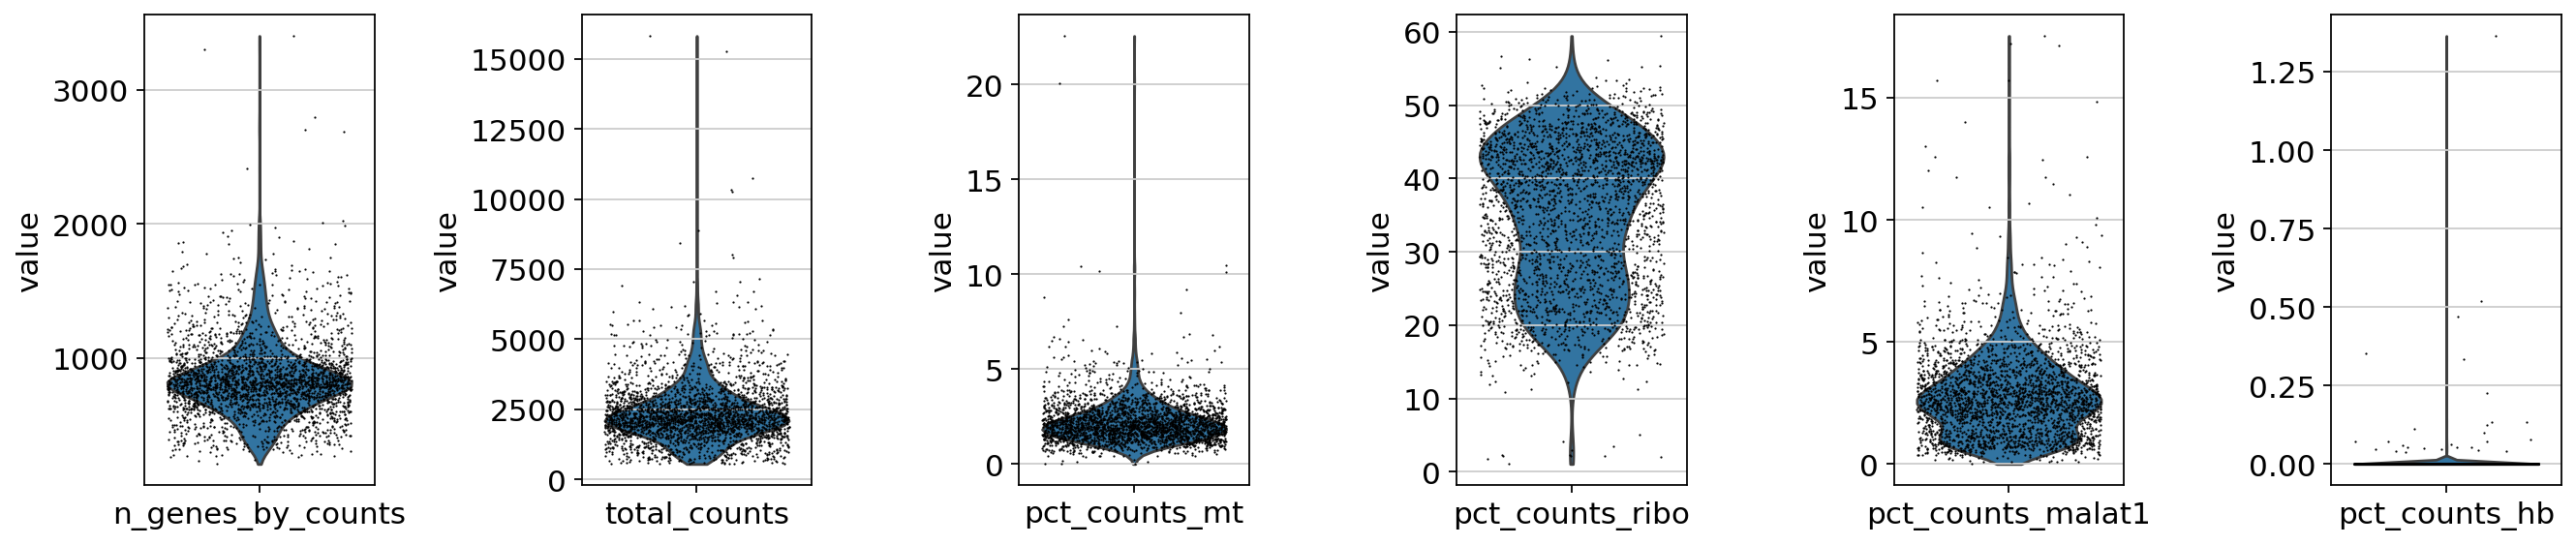

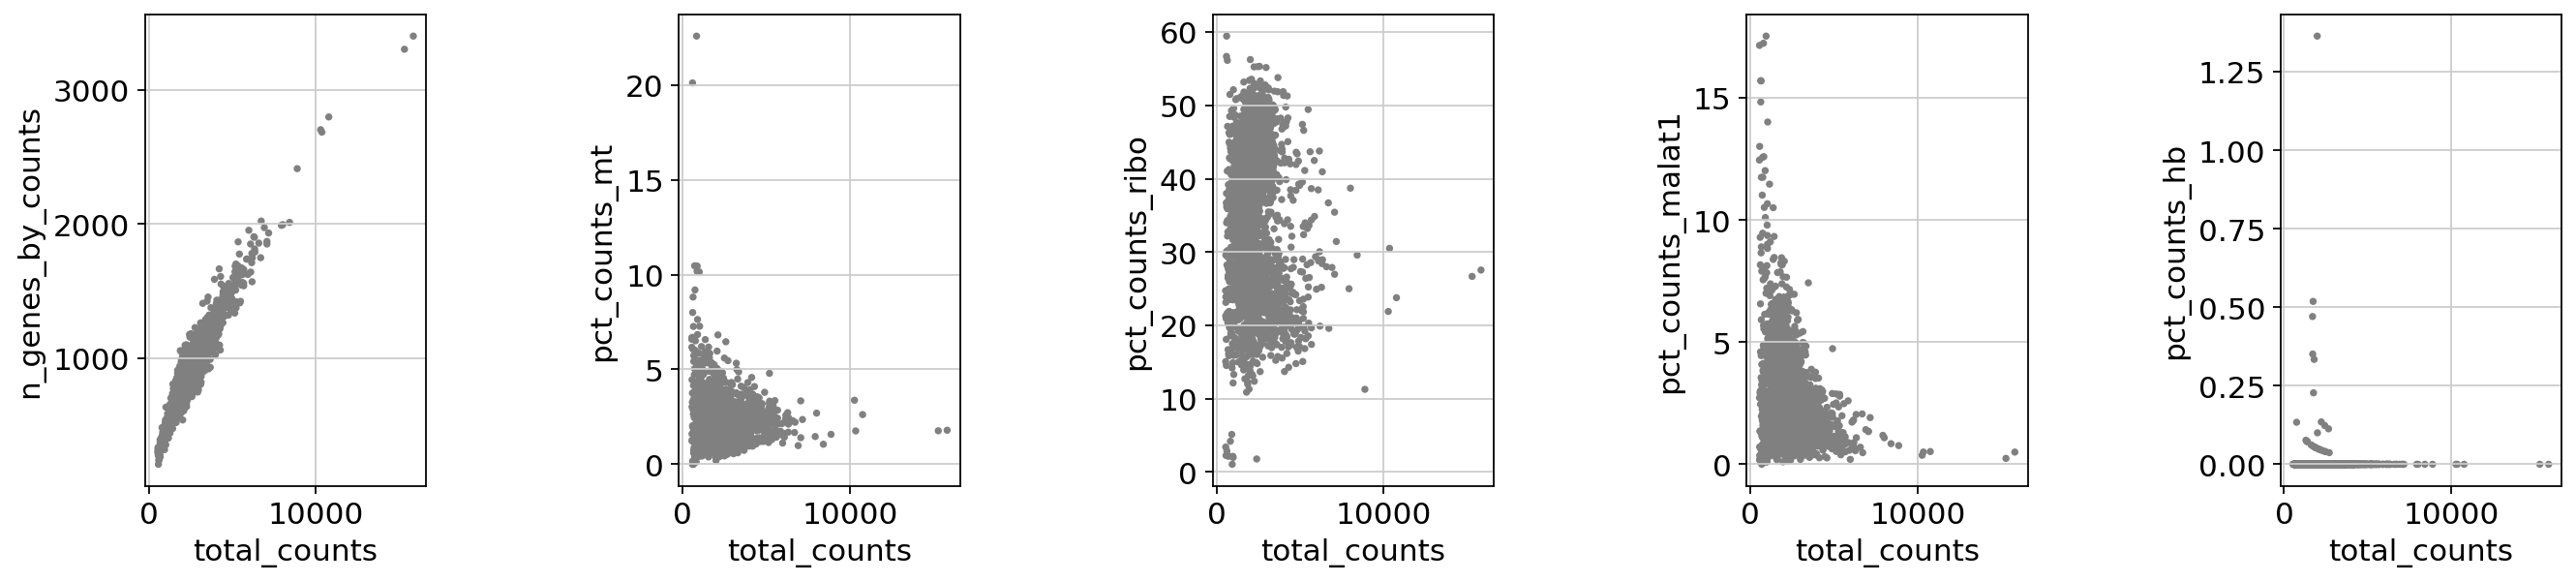

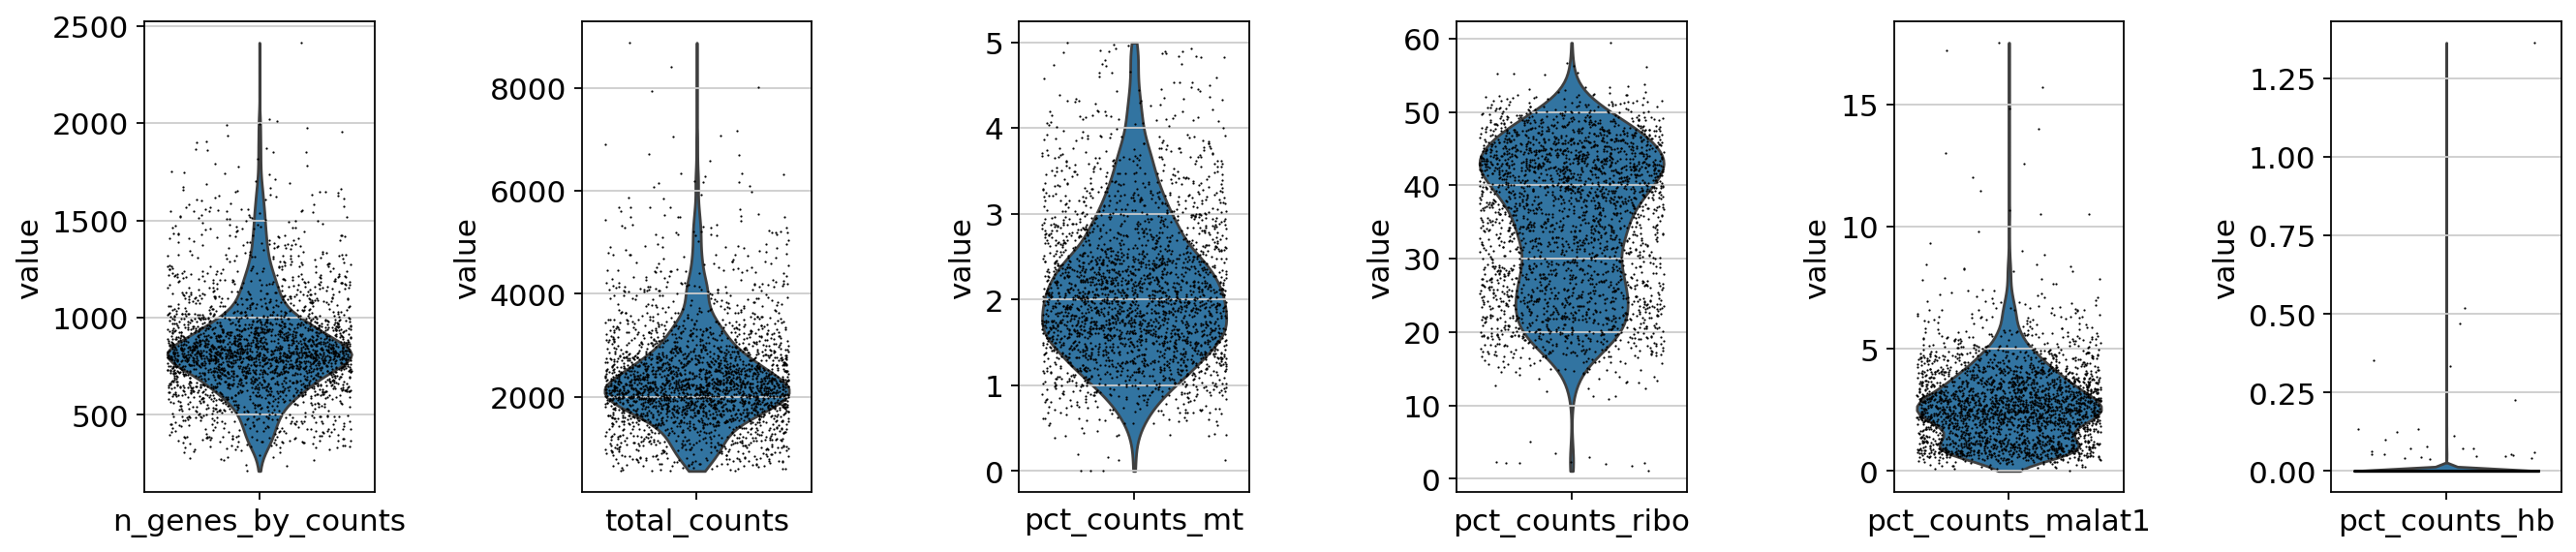

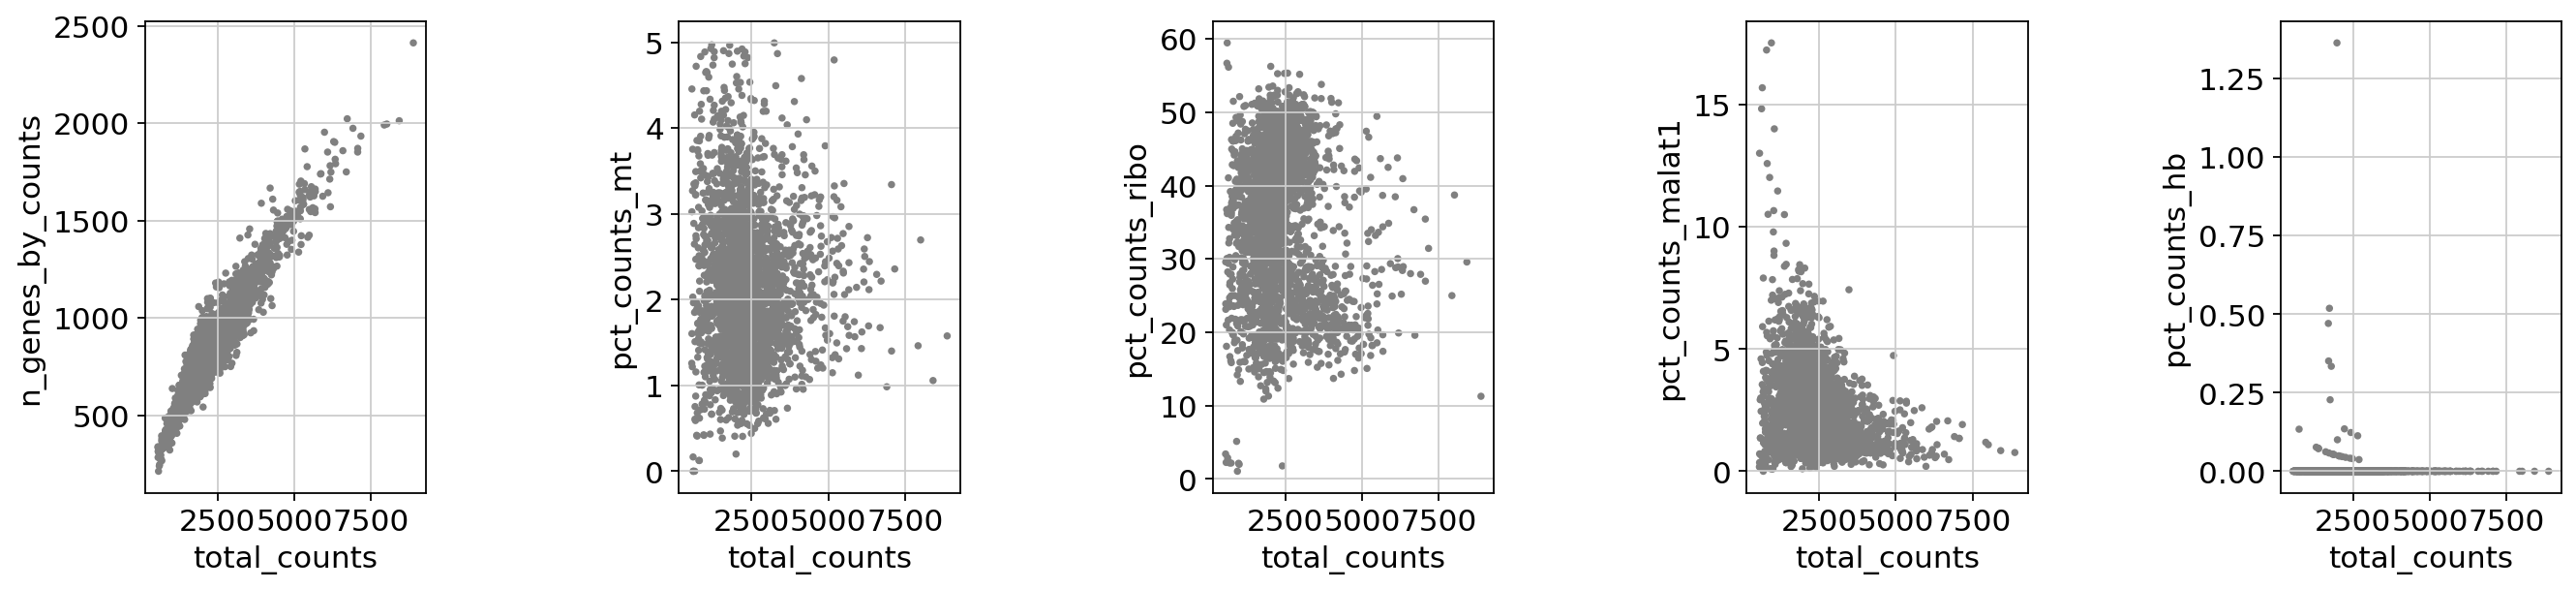

In [12]:
### QC
pbmc3k_sctl_DATASET.basic_filitering()
pbmc3k_sctl_DATASET.annotate_n_view_adata_raw_counts()
pbmc3k_sctl_DATASET.filter_cells_by_anotated_QC_gene()
pbmc3k_sctl_DATASET.remove_genes()
pbmc3k_sctl_DATASET.annotate_n_view_adata_raw_counts()

### data transforms and clustering

####################################################  save raw counts (adata.X) to adata.layers["counts"]
####################################################  library-size correct  the data  target_sum= 10000.0
####################################################  Logarithmize  the data
############################# to adata.raw save filtered, normalized and logarithmized gene expression and plot
############### HVG_flavor=seurat
############################# the number of highly varriable gens are =  1838


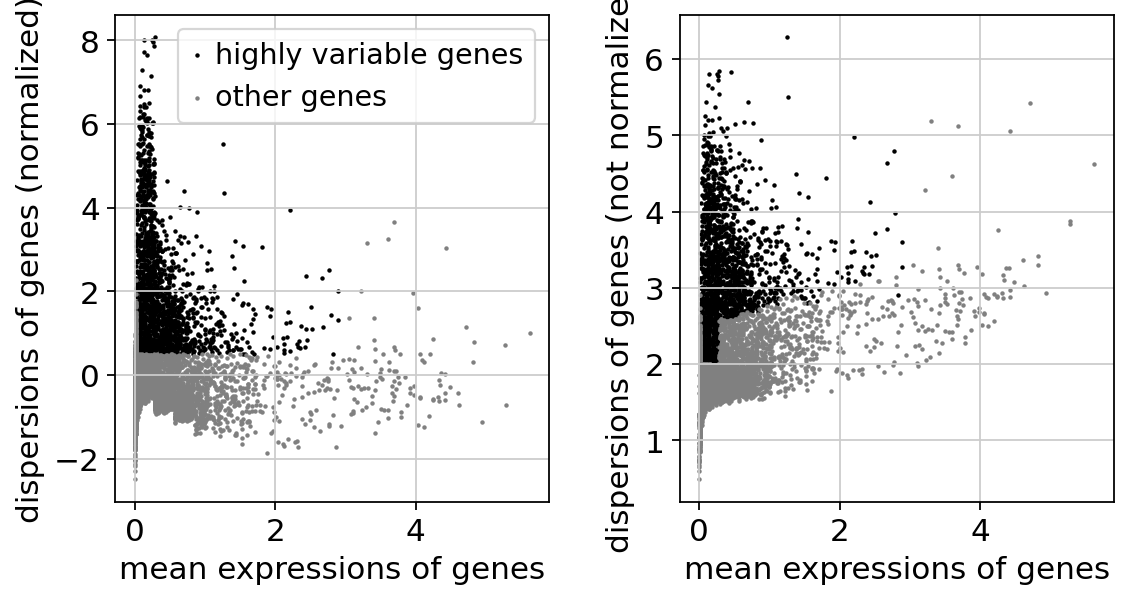

 Before  filtering for highly_variable genes : number of Cells 2638, number of genes 13714
 filter_HVG = True ... only highly_variable gene will be kept 
 AFTER  filtering for highly_variable genes: number of Cells 2638, number of genes 1838
####################################################  regress_out_anotated_QC_genes 
we are regressing out  total_counts True
we are regressing out  pct_counts_mt True
we are regressing out  pct_counts_ribo False
we are regressing out  pct_counts_malat1 False
we are regressing out  pct_counts_hb False
n_jobs= n_jobs=16


/home/ubuntu/miniconda3/envs/not_base/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:709: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


####################################################  Now running sc.pp.scale() Scale the data (each gene to unit variance)
 scale_max_std_value= 10
####################################################  calc_cell_cycle_score
we are calc_cell_cycle_score True/Flase = True
running calc_cell_cycle_score(adata)
############# WARNING data should be scaled first if planing on regressing out cell cycle score
Organism is human, using  human cell cycle genes
 there are 43 s_genes   54 g2m_genes  97 cell_cycle_genes
 there are 7 cell_cycle_genes in the dataset
       'ANLN', 'GAS2L3'],
      dtype='object')


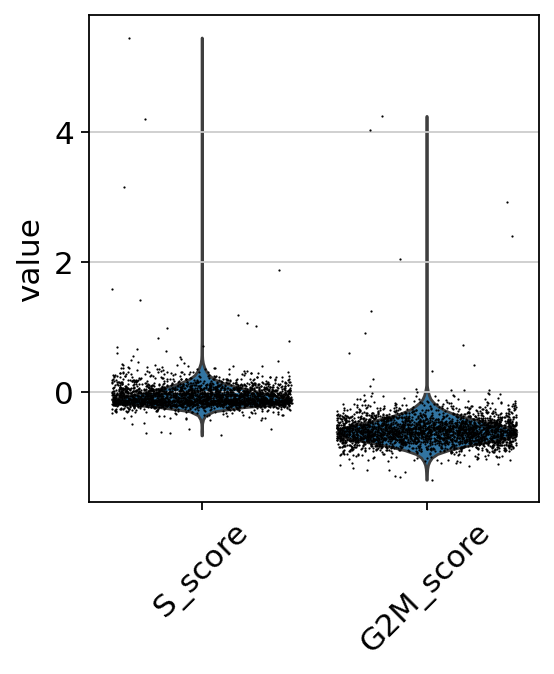

we are regressing out  cell_cycle_score True/Flase = False
####################################################  Principal component analysis


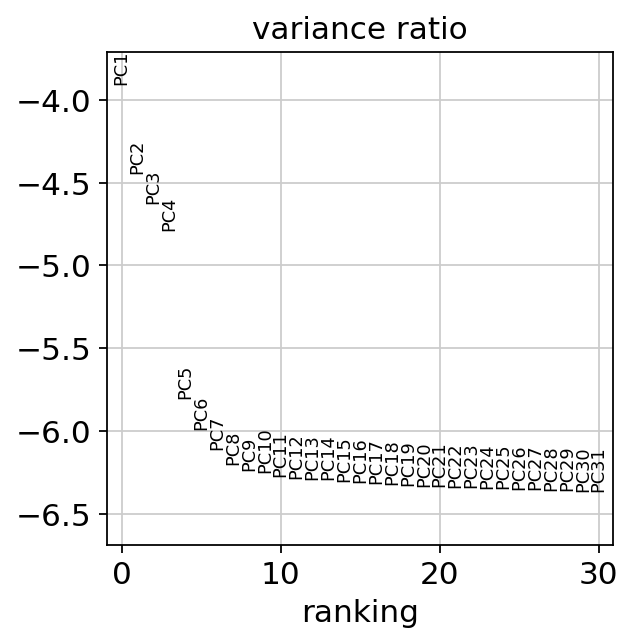

/efs/general/blewis/projects/gitbenlewis/single_cell_python_tools/Example_notebooks/01_PBMC3k/../../../single_cell_python_tools/preprocessing/_clustering.py:19: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=leiden_res,key_added=key_added)


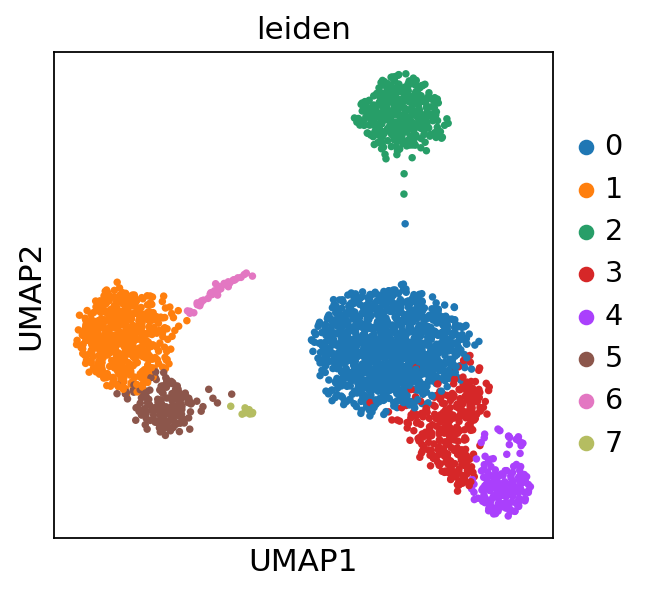

In [13]:
### data transforms and clustering
pbmc3k_sctl_DATASET.process2scaledPCA()
pbmc3k_sctl_DATASET.leiden_clustering()
pbmc3k_sctl_DATASET.rename_leiden_clusters()

### UMAP plots

 Average silhoutte score = 0.12454729527235031 for 8 clusters at leiden resolution of 0.9


/efs/general/blewis/projects/gitbenlewis/single_cell_python_tools/Example_notebooks/01_PBMC3k/../../../single_cell_python_tools/plotting/_plots.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_silhouette_score_list=cluster_silhouette_score_list=adata.obs.groupby('leiden')[f'silhoutte'].mean()


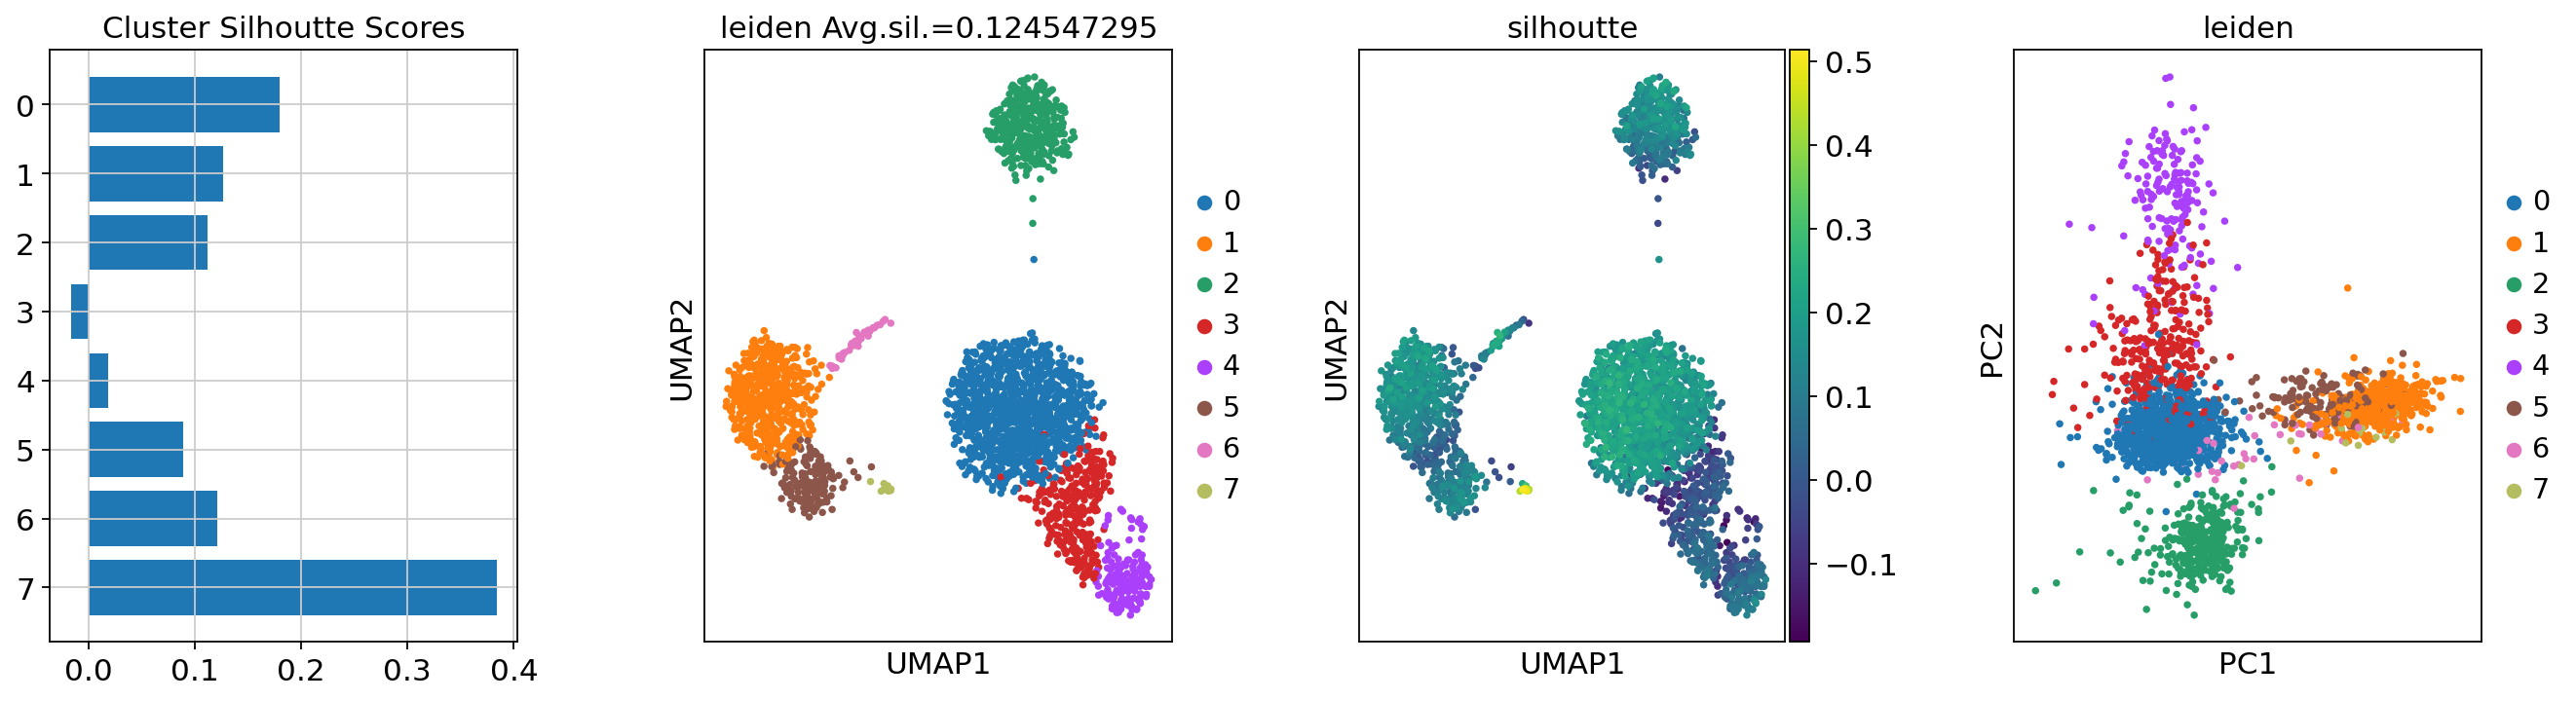

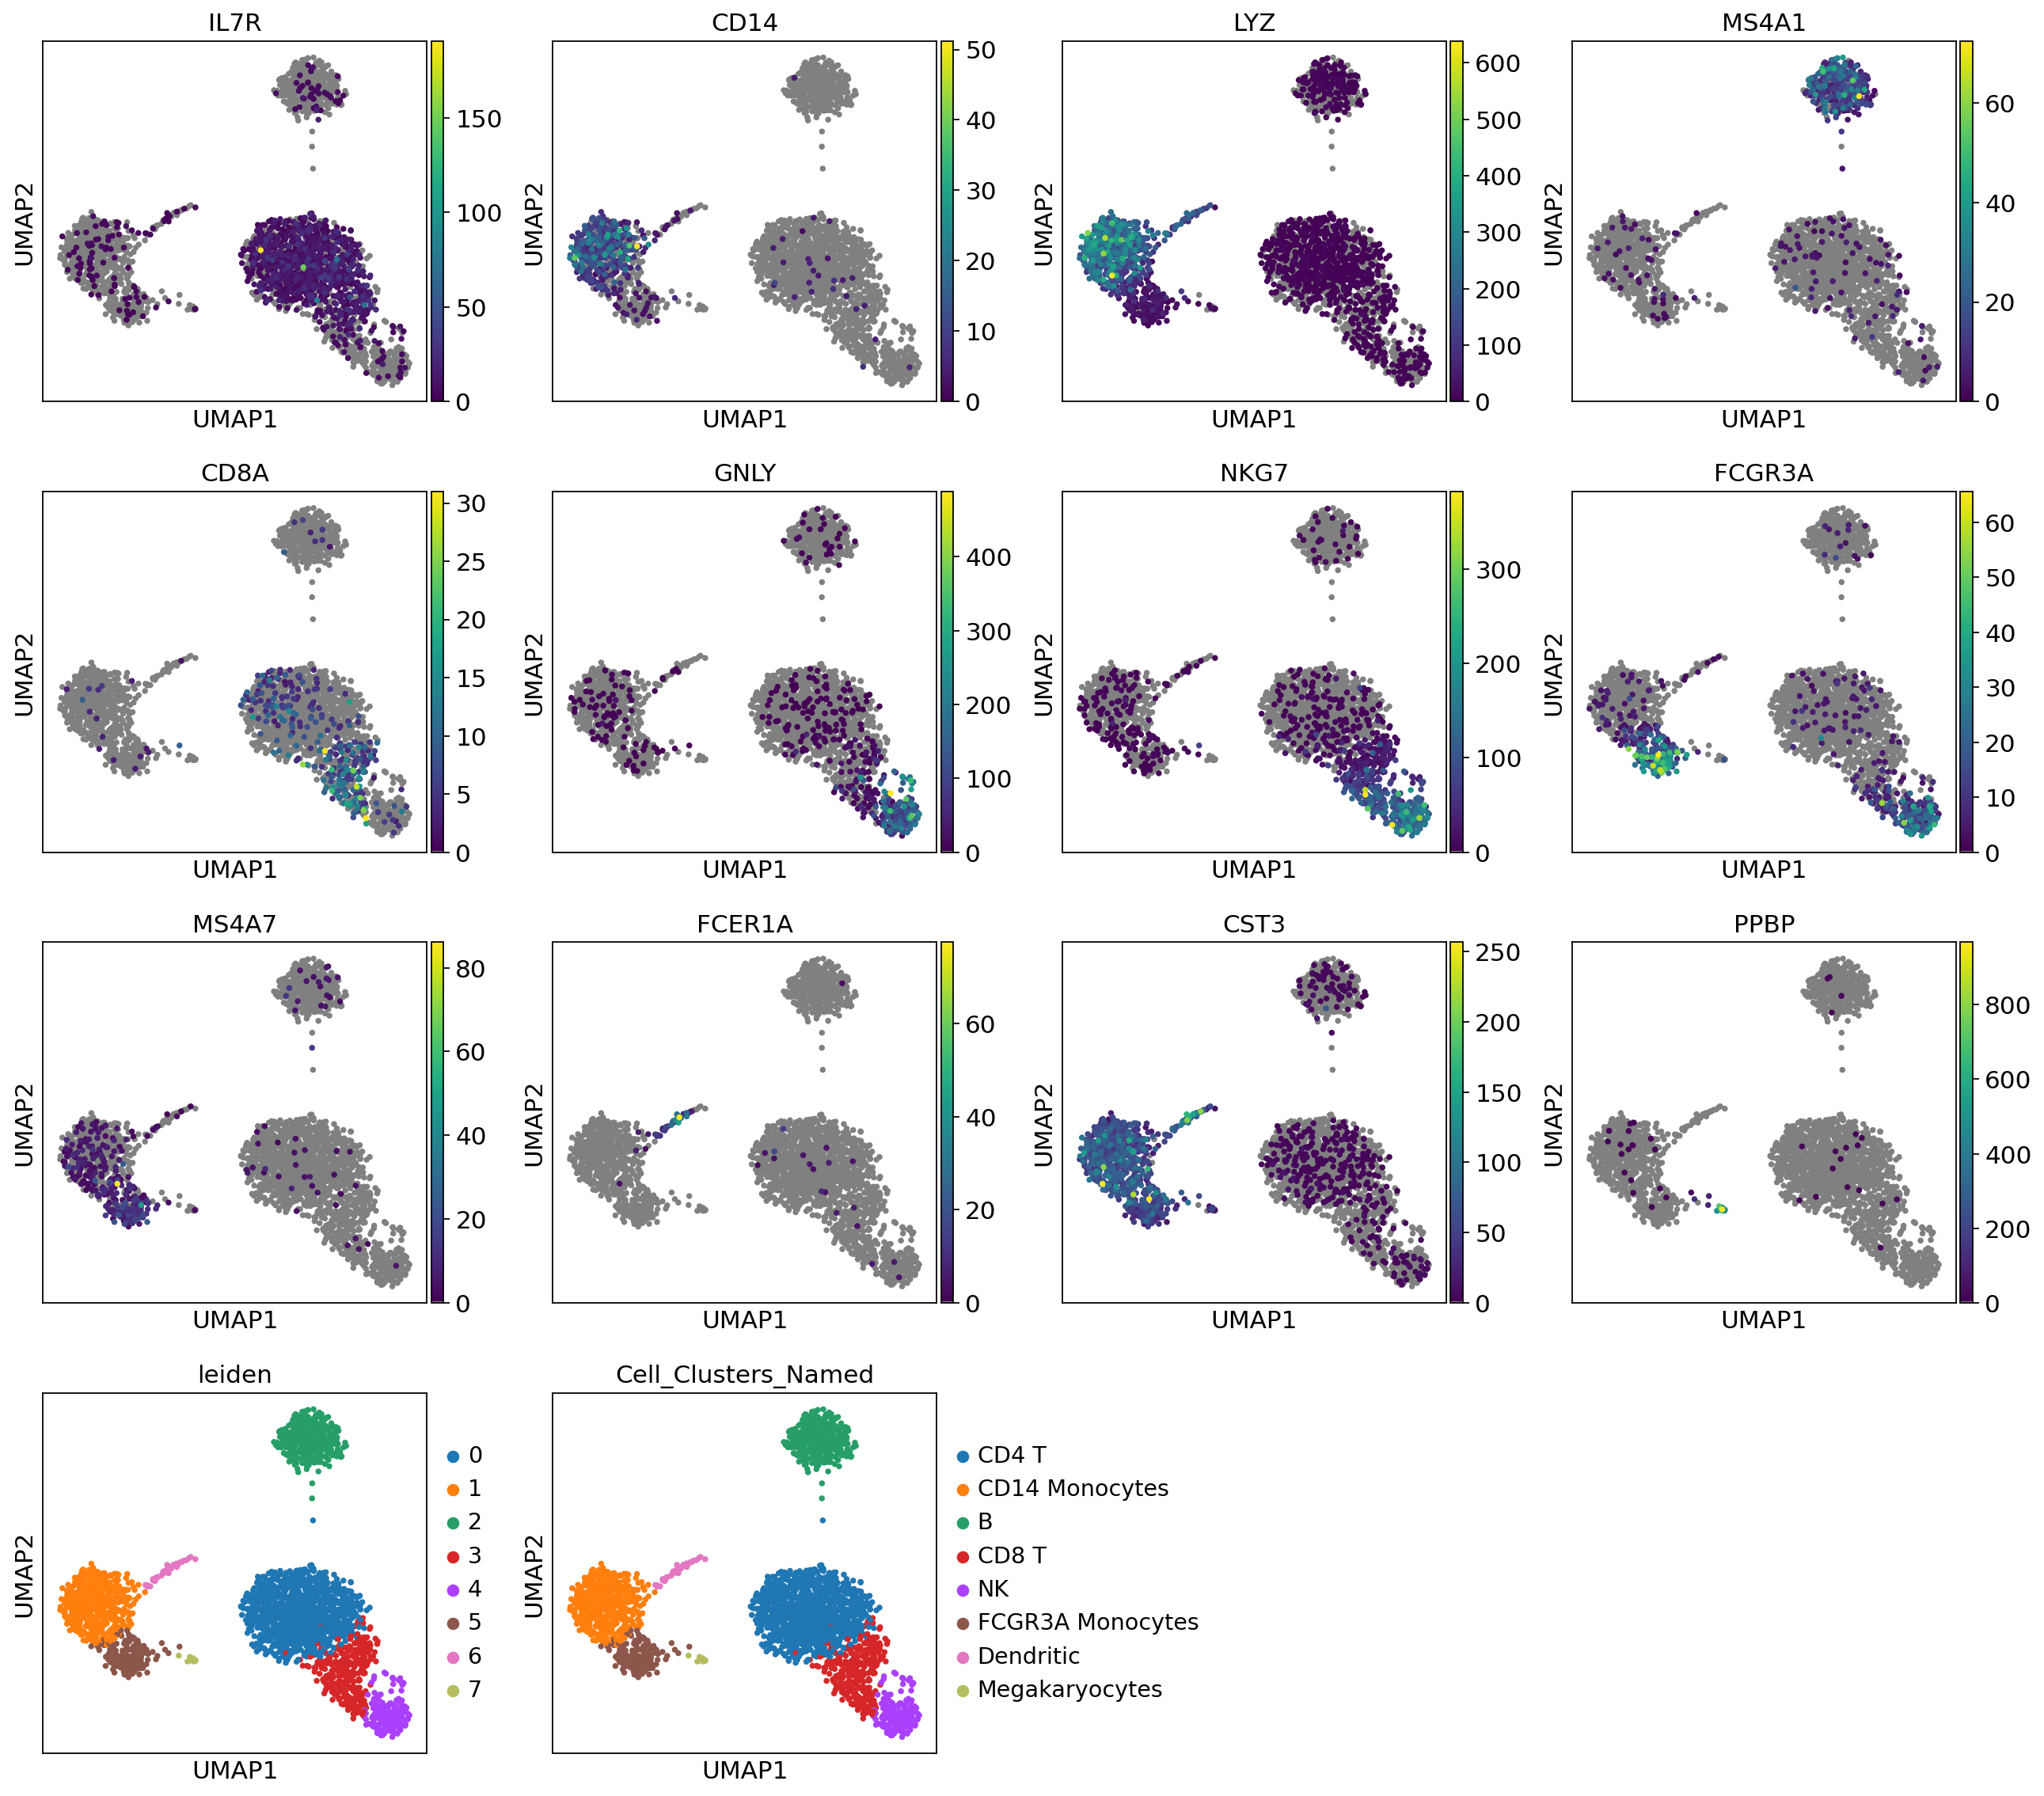

In [14]:

### UMAP plots
pbmc3k_sctl_DATASET.silhouette_score_n_plot()
pbmc3k_sctl_DATASET.marker_gene_umaps(palette=None)

## run sctl.tl.rank_genes() 

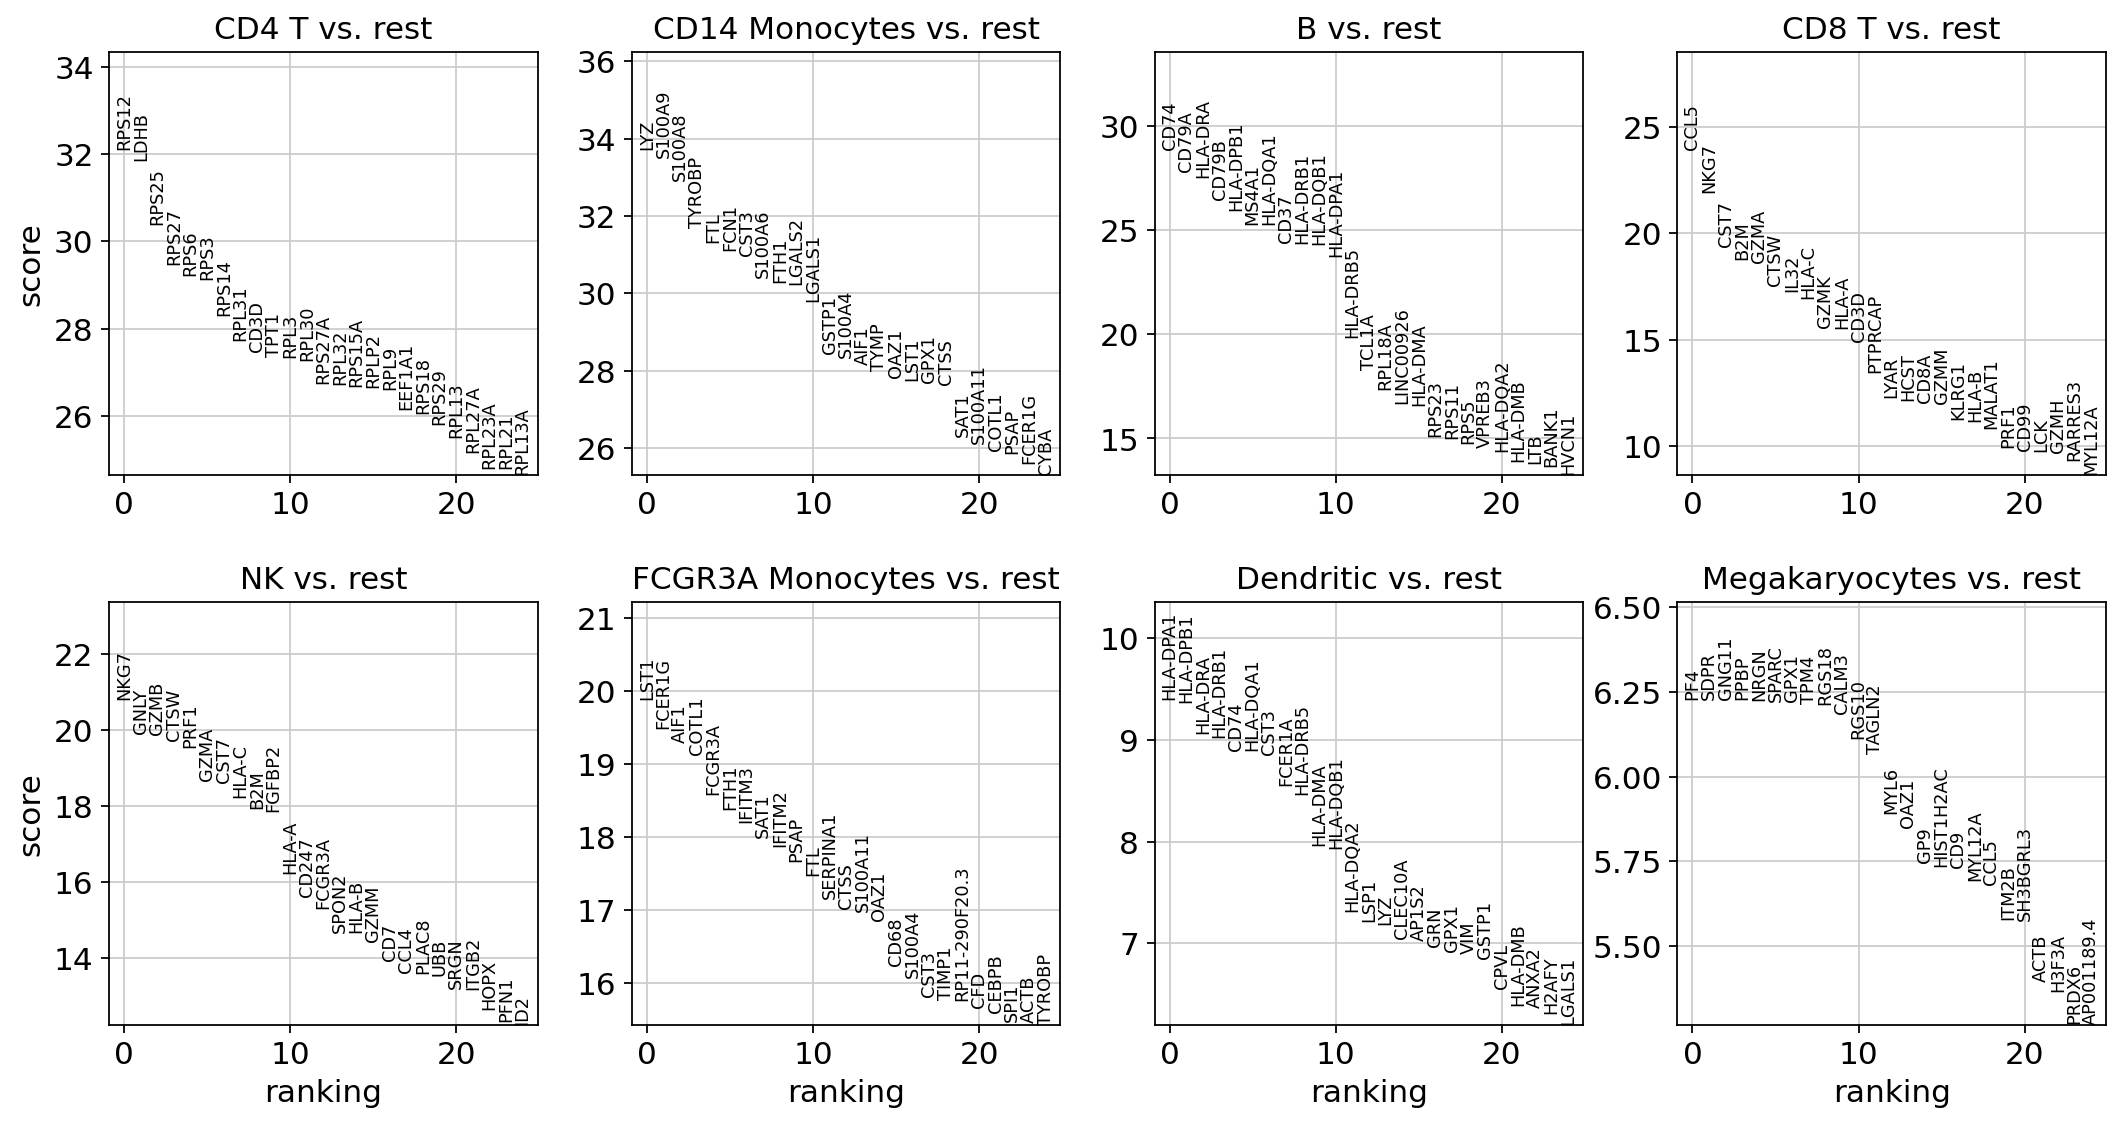

/home/ubuntu/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


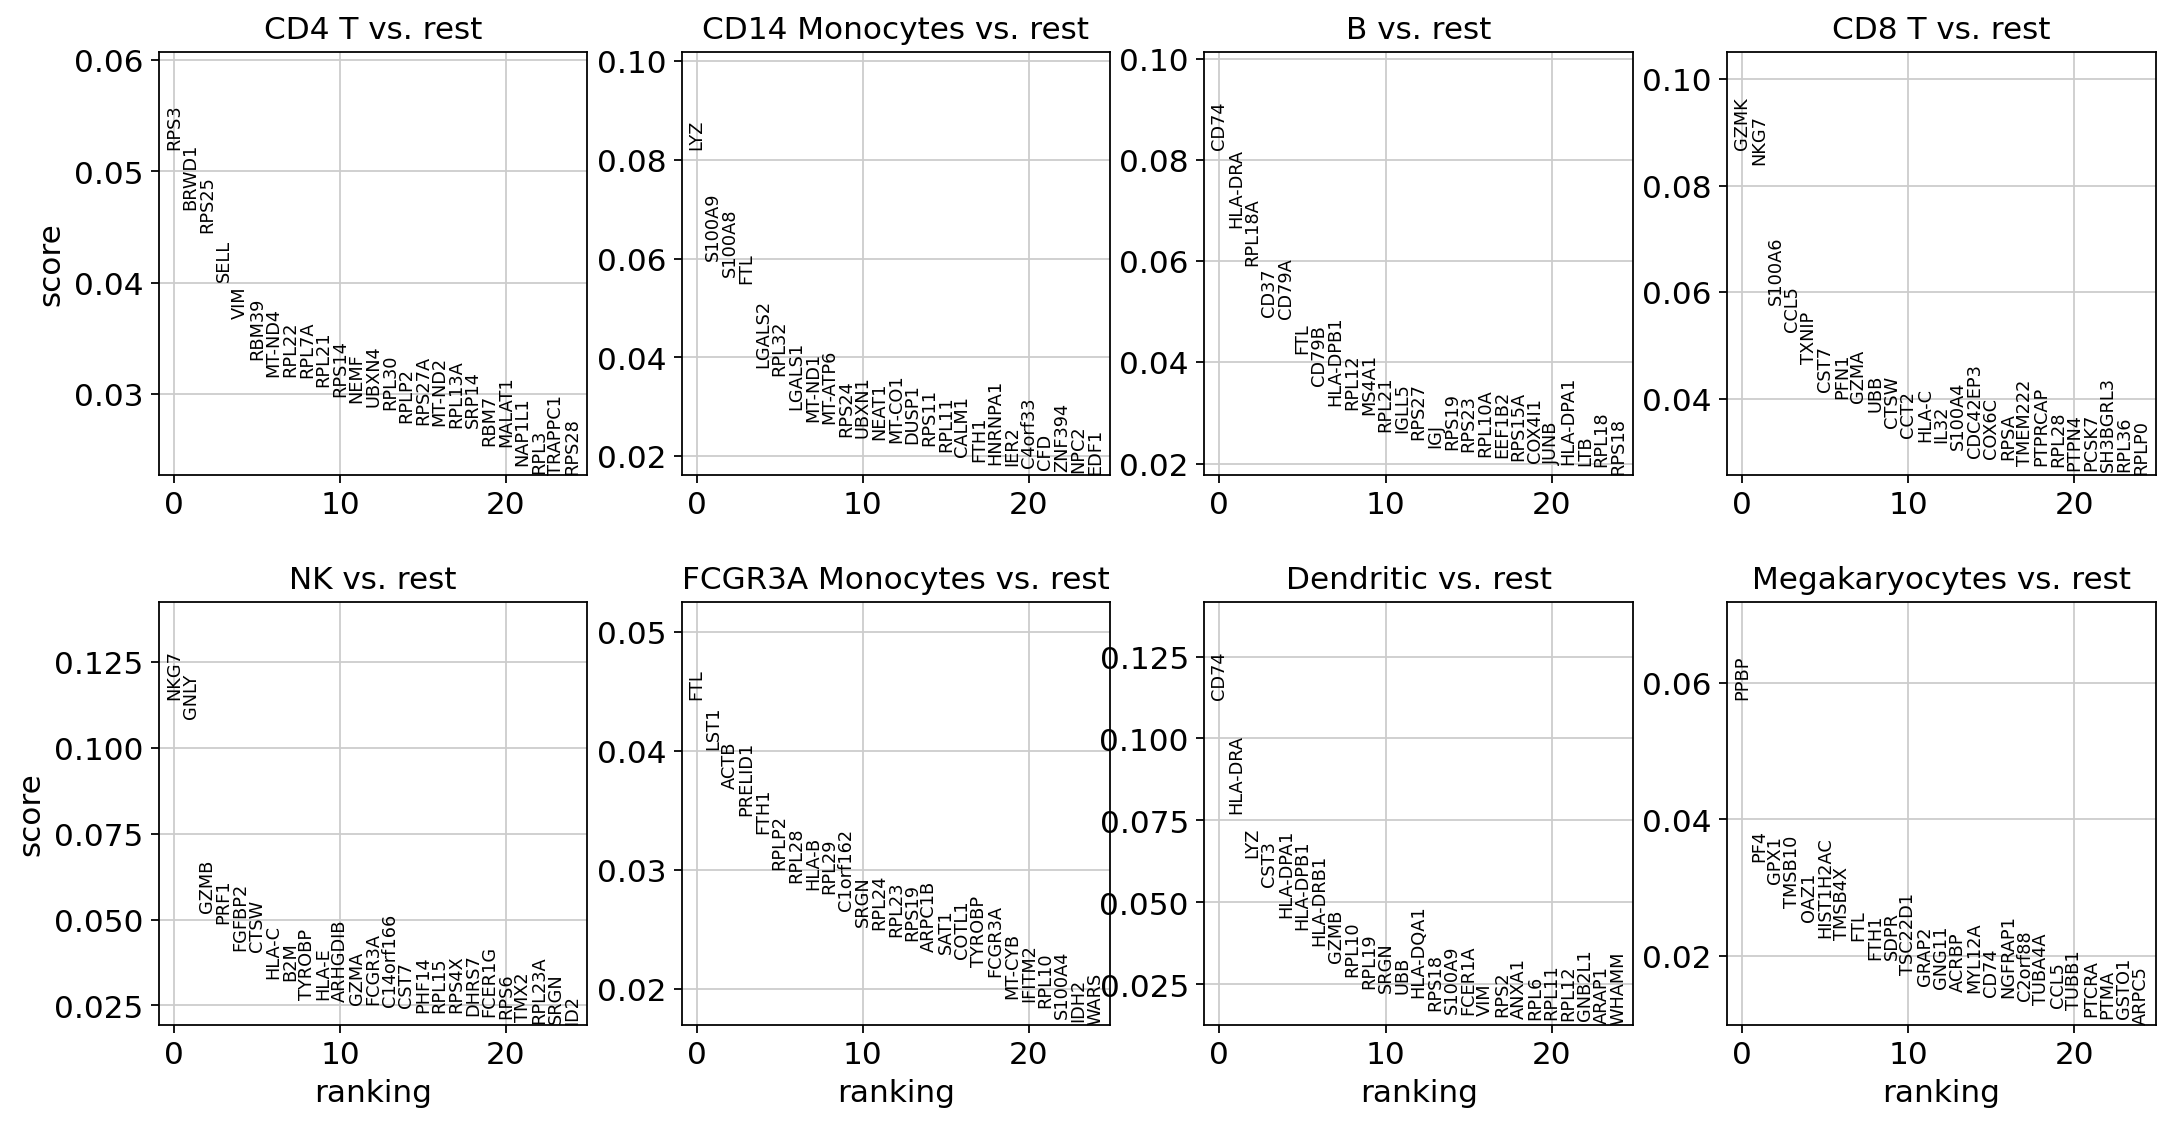

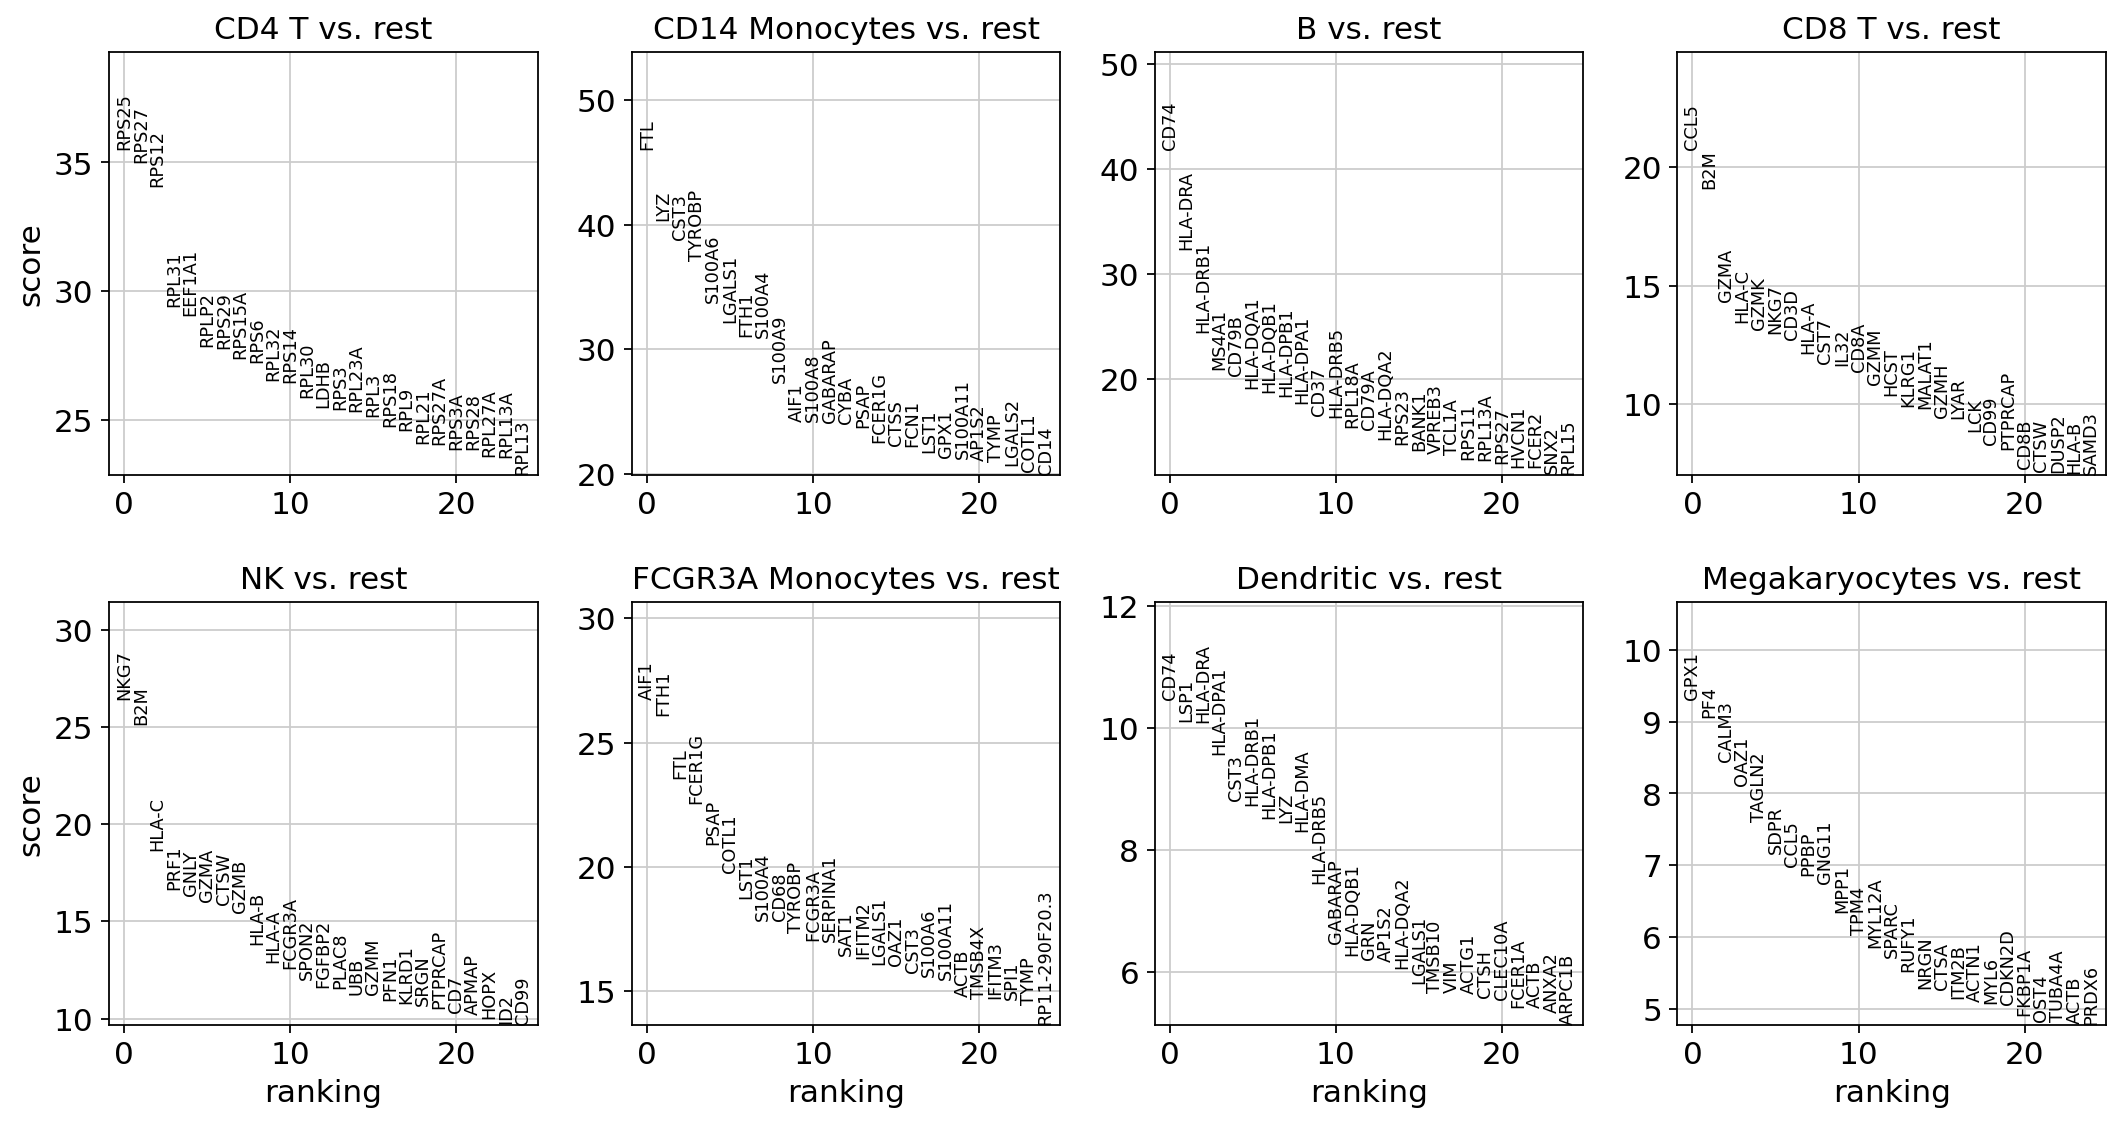

In [15]:
rank_genes_groups_wilcox, rank_genes_groups_logreg,rank_genes_groups_t_test = sctl.tl.rank_genes(pbmc3k_sctl_DATASET.adata,
               wilcox=True,logreg=True,t_test=True,rank_use_raw=True,obs_key="Cell_Clusters_Named",**parameters
                 )

## run sctl.tl.GSEA_enrichr_all_clusters() 


In [16]:
sctl.tl.GSEA_enrichr_all_clusters(test_library_names=['GO_Biological_Process_2021','GO_Cellular_Component_2021','GO_Molecular_Function_2021'],
 top_nth=10,**parameters )

logreg: the full_table  is 13714 genes long by 8 columns for 8 clusters
logreg: the foreground list is 1371 genes long
<CLUSTER 0> for logreg gene rank top 3 background genes ['RPS3', 'BRWD1', 'RPS25'], bottom 3 background genes ['HLA-DRA', 'CD74', 'NKG7'] 
<CLUSTER 0> for logreg gene rank top 3 foreground genes ['RPS3', 'BRWD1', 'RPS25'], bottom 3 foreground genes ['APEX2', 'CNPY4', 'CCNT2'] 
<CLUSTER 1> for logreg gene rank top 3 background genes ['LYZ', 'S100A9', 'S100A8'], bottom 3 background genes ['RPL18A', 'RPL28', 'PRELID1'] 
<CLUSTER 1> for logreg gene rank top 3 foreground genes ['LYZ', 'S100A9', 'S100A8'], bottom 3 foreground genes ['PPP6R1', 'STK11', 'GM2A'] 
<CLUSTER 2> for logreg gene rank top 3 background genes ['CD74', 'HLA-DRA', 'RPL18A'], bottom 3 background genes ['SELL', 'ACTB', 'LYZ'] 
<CLUSTER 2> for logreg gene rank top 3 foreground genes ['CD74', 'HLA-DRA', 'RPL18A'], bottom 3 foreground genes ['CENPH', 'RCE1', 'RP11-488C13.5'] 
<CLUSTER 3> for logreg gene rank 